In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential

Epoch 1/35


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.5589 - mae: 0.5747 - val_loss: 0.3873 - val_mae: 0.4817 - learning_rate: 0.0010
Epoch 2/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3190 - mae: 0.4399 - val_loss: 0.2620 - val_mae: 0.3885 - learning_rate: 0.0010
Epoch 3/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.2206 - mae: 0.3675 - val_loss: 0.1726 - val_mae: 0.3114 - learning_rate: 0.0010
Epoch 4/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.1681 - mae: 0.3231 - val_loss: 0.1488 - val_mae: 0.2858 - learning_rate: 0.0010
Epoch 5/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.1444 - mae: 0.3050 - val_loss: 0.1252 - val_mae: 0.2695 - learning_rate: 0.0010
Epoch 6/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.1289 - mae: 0.2873 - val_loss: 0.1192 - val_mae: 0.2662 - learning_rate: 0.0010
Epoch 7/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1165 - mae: 0.2709 - val_loss: 0.1057 - val_mae: 0.2472 - learning_rate: 0.0010
Epoch 8/35
27/27 ━━━━━━━

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
--- Métricas Globais do Conjunto de Teste ---
RMSE: 0.333 m/s | MAE: 0.255 m/s | R²: 0.927 | Pearson (r): 0.967



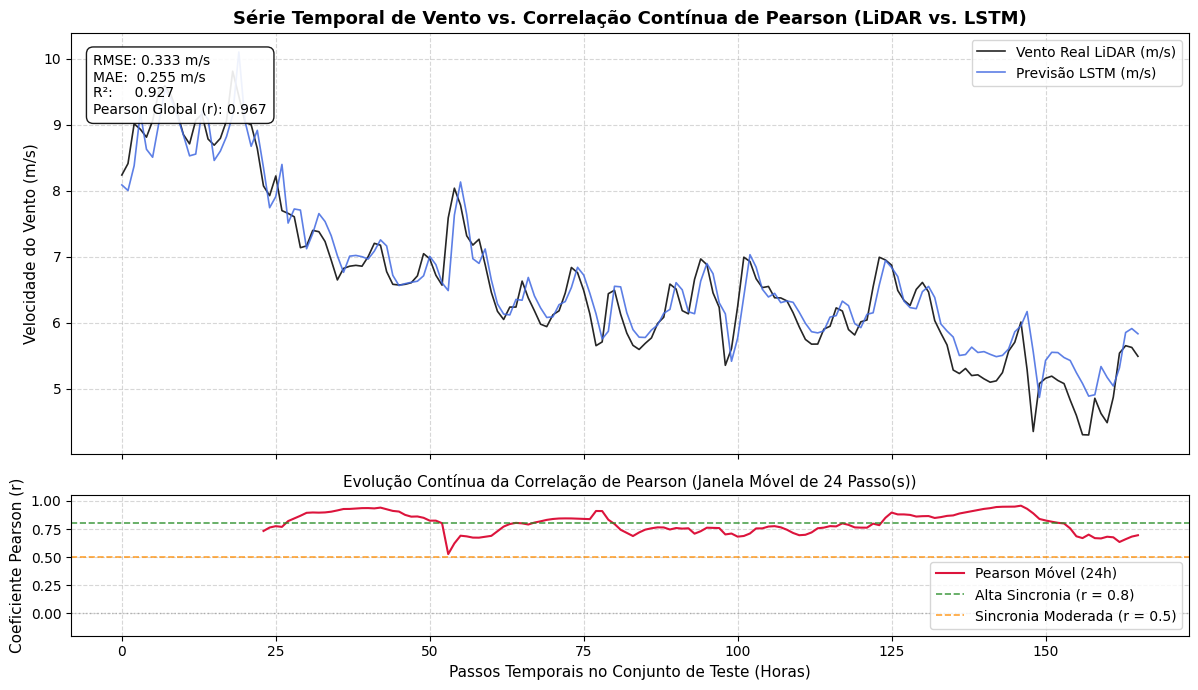

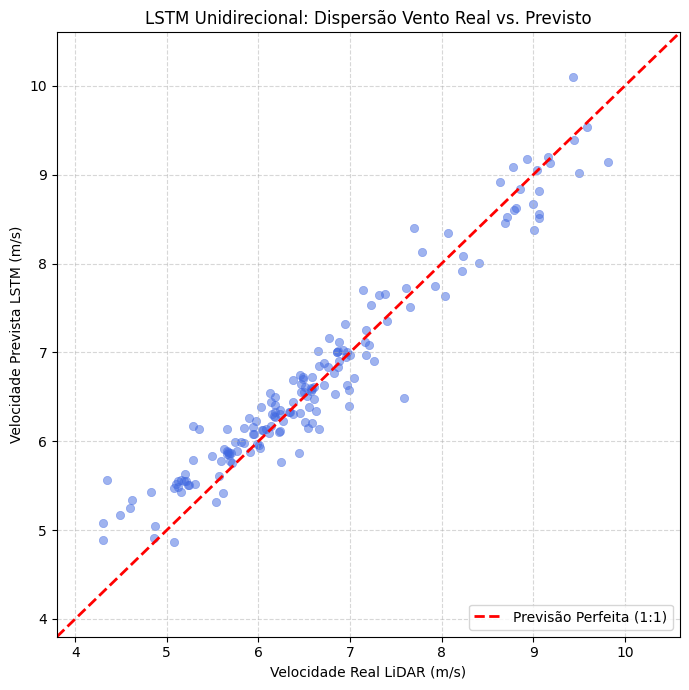

In [ ]:
# ==========================================
# 1. CARREGAMENTO E DIVISÃO TEMPORAL
# Teste 1, o modelo deve se "auto-prever"
# ==========================================
df = pd.read_parquet("data/approach_a.parquet")

features = ["ws100_era5"]
target = "ws100_era5"

n = len(df)
train_df = df.iloc[: int(n * 0.7)]
val_df = df.iloc[int(n * 0.7) : int(n * 0.85)]
test_df = df.iloc[int(n * 0.85) :]

# ==========================================
# 2. NORMALIZAÇÃO SEPARADA (X e Y)
# ==========================================
scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_train_raw = scaler_x.fit_transform(train_df[features])
y_train_raw = scaler_y.fit_transform(train_df[[target]])

X_val_raw = scaler_x.transform(val_df[features])
y_val_raw = scaler_y.transform(val_df[[target]])

X_test_raw = scaler_x.transform(test_df[features])
y_test_raw = scaler_y.transform(test_df[[target]])

# ==========================================
# 3. JANELA DESLIZANTE (SLIDING WINDOW)
# ==========================================
def create_sequences(X_data, y_data, lookback=24):
  X_out, y_out = [], []
  for i in range(len(X_data) - lookback):
    X_out.append(X_data[i : i + lookback, :])
    y_out.append(y_data[i + lookback, 0])
  return np.array(X_out), np.array(y_out)

LOOKBACK = 24  # Usa as últimas 24h/timestamps para prever a hora seguinte
X_train, y_train = create_sequences(X_train_raw, y_train_raw, LOOKBACK)
X_val, y_val = create_sequences(X_val_raw, y_val_raw, LOOKBACK)
X_test, y_test = create_sequences(X_test_raw, y_test_raw, LOOKBACK)

# ==========================================
# 4. MODELO LSTM UNIDIRECIONAL
# ==========================================
# O modelo está configurado para 32 batchs, de ciclos de 24 timestamps
model = Sequential([
    LSTM(
        64, activation="tanh", input_shape=(X_train.shape[1], X_train.shape[2])
    ),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1),
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])

# Callbacks para otimização de treinamento
early_stop = EarlyStopping(
    monitor="val_loss", patience=7, restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=35,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)

# ==========================================
# 5. INFERÊNCIA E MÉTRICAS
# ==========================================
y_pred_scaled = model.predict(X_test)

y_real = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()

rmse = np.sqrt(mean_squared_error(y_real, y_pred))
mae = mean_absolute_error(y_real, y_pred)
r2 = r2_score(y_real, y_pred)
pearson_global = np.corrcoef(y_real, y_pred)[0, 1]

print(f"--- Métricas Globais do Conjunto de Teste ---")
print(
    f"RMSE: {rmse:.3f} m/s | MAE: {mae:.3f} m/s | R²: {r2:.3f} | Pearson (r):"
    f" {pearson_global:.3f}\n"
)

# ==========================================
# 6. CÁLCULO DA CORRELAÇÃO DE PEARSON MÓVEL (ROLLING)
# ==========================================
# Converte para Pandas Series para aplicar a janela deslizante de correlação
s_real = pd.Series(y_real)
s_pred = pd.Series(y_pred)

# Define a janela de correlação (ex.: 24 passos = 24 horas na Abordagem A)
WINDOW_CORR = 24
rolling_pearson = s_real.rolling(window=WINDOW_CORR).corr(s_pred)

# ==========================================
# 7. VISUALIZAÇÃO CONTÍNUA DUAL-PANEL (SÉRIE + CORRELAÇÃO MÓVEL)
# ==========================================
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(12, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)

# --- PAINEL SUPERIOR: Série Temporal Real vs. Previsto ---
ax1.plot(
    y_real,
    label="Vento Real LiDAR (m/s)",
    color="black",
    linewidth=1.2,
    alpha=0.85,
)
ax1.plot(
    y_pred,
    label="Previsão LSTM (m/s)",
    color="royalblue",
    linewidth=1.2,
    alpha=0.85,
)
ax1.set_title(
    "Série Temporal de Vento vs. Correlação Contínua de Pearson (LiDAR vs."
    " LSTM)",
    fontsize=13,
    fontweight="bold",
)
ax1.set_ylabel("Velocidade do Vento (m/s)", fontsize=11)
ax1.legend(loc="upper right", frameon=True, facecolor="white")
ax1.grid(True, linestyle="--", alpha=0.5)

# --- PAINEL INFERIOR: Correlação de Pearson Móvel ---
ax2.plot(
    rolling_pearson,
    color="crimson",
    linewidth=1.5,
    label=f"Pearson Móvel ({WINDOW_CORR}h)",
)
ax2.axhline(
    y=0.8,
    color="forestgreen",
    linestyle="--",
    linewidth=1.2,
    alpha=0.8,
    label="Alta Sincronia (r = 0.8)",
)
ax2.axhline(
    y=0.5,
    color="darkorange",
    linestyle="--",
    linewidth=1.2,
    alpha=0.8,
    label="Sincronia Moderada (r = 0.5)",
)
ax2.axhline(y=0.0, color="gray", linestyle=":", linewidth=1.0, alpha=0.5)

ax2.set_title(
    f"Evolução Contínua da Correlação de Pearson (Janela Móvel de"
    f" {WINDOW_CORR} Passo(s))",
    fontsize=11,
)
ax2.set_xlabel("Passos Temporais no Conjunto de Teste (Horas)", fontsize=11)
ax2.set_ylabel("Coeficiente Pearson (r)", fontsize=11)
ax2.set_ylim(-0.2, 1.05)
ax2.legend(loc="lower right", frameon=True, facecolor="white")
ax2.grid(True, linestyle="--", alpha=0.5)

# Adiciona caixa informativa de métricas no gráfico superior
metrics_text = (
    f"RMSE: {rmse:.3f} m/s\nMAE:  {mae:.3f} m/s\nR²:     {r2:.3f}\nPearson Global"
    f" (r): {pearson_global:.3f}"
)
ax1.text(
    0.02,
    0.95,
    metrics_text,
    transform=ax1.transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.9),
)

plt.tight_layout()
plt.show()

# ==========================================
# 8. GRÁFICO DE DISPERSÃO (1:1 SCATTER PLOT)
# ==========================================
plt.figure(figsize=(7, 7))
sns.scatterplot(
    x=y_real, y=y_pred, alpha=0.5, color="royalblue", edgecolor=None
)

min_val = min(y_real.min(), y_pred.min()) - 0.5
max_val = max(y_real.max(), y_pred.max()) + 0.5
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    lw=2,
    label="Previsão Perfeita (1:1)",
)

plt.title(
    "LSTM Unidirecional: Dispersão Vento Real vs. Previsto", fontsize=12
)
plt.xlabel("Velocidade Real LiDAR (m/s)", fontsize=10)
plt.ylabel("Velocidade Prevista LSTM (m/s)", fontsize=10)
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Formato de X_train (Amostras, Histórico, Atributos): (857, 24, 1)
Formato de y_train (Amostras, Horizonte Futuro): (857, 6)

Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 0.7977 - mae: 0.6979 - val_loss: 0.7784 - val_mae: 0.7106 - learning_rate: 0.0010
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.5637 - mae: 0.5837 - val_loss: 0.7259 - val_mae: 0.6815 - learning_rate: 0.0010
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.5070 - mae: 0.5554 - val_loss: 0.6505 - val_mae: 0.6379 - learning_rate: 0.0010
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.4737 - mae: 0.5362 - val_loss: 0.6084 - val_mae: 0.6102 - learning_rate: 0.0010
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.4263 - mae: 0.5052 - val_loss: 0.6317 - val_mae: 0.6386 - learning_rate: 0.0010
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4253 - mae: 0.5024 - val_loss: 0.5532 - val_mae: 0.5938 - learning_rate: 0.0010
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.4004 - mae: 0.4853 - val_loss: 0.5342 - val_mae: 0.5740 - learning_rate: 0.0010
Epoch 8/50
27/27 ━━━━━━━

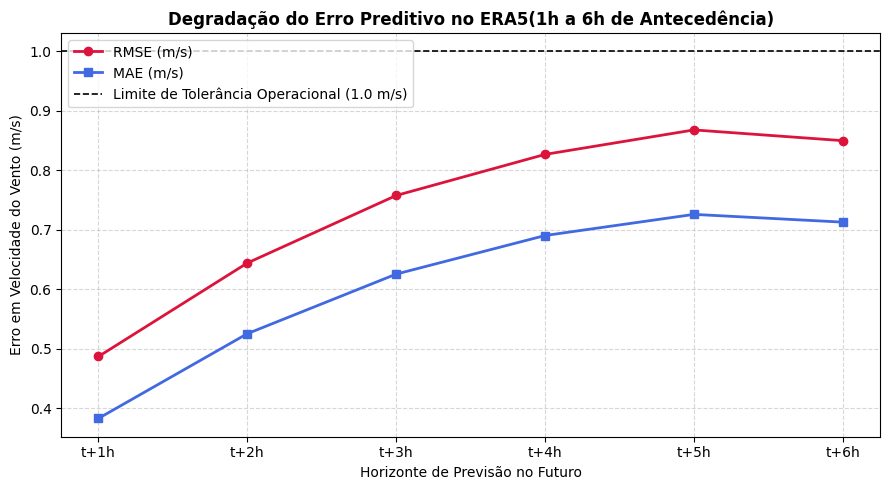

In [ ]:
# ==========================================
# 9. CRIAÇÃO DE SEQUÊNCIAS MULTI-STEP (24h(1 passo) -> 6h)
# A ideia é entender se o modelo é capaz de se auto-prever em um horizonte de 6 passos
# ==========================================
def create_multistep_sequences(X_data, y_data, lookback=24, horizon=6):
  X_out, y_out = [], []
  # Garante que haja pontos suficientes para cobrir o lookback E o horizonte completo
  for i in range(len(X_data) - lookback - horizon + 1):
    X_out.append(X_data[i : i + lookback, :])
    # Extrai um vetor de 'horizon' (6) valores futuros para o alvo Y
    y_out.append(y_data[i + lookback : i + lookback + horizon, 0])
  return np.array(X_out), np.array(y_out)

LOOKBACK = 24  # 24 horas de histórico passado
HORIZON = 6  # 6 horas de previsão futura

X_train, y_train = create_multistep_sequences(
    X_train_raw, y_train_raw, LOOKBACK, HORIZON
)
X_val, y_val = create_multistep_sequences(
    X_val_raw, y_val_raw, LOOKBACK, HORIZON
)
X_test, y_test = create_multistep_sequences(
    X_test_raw, y_test_raw, LOOKBACK, HORIZON
)

print(
    f"Formato de X_train (Amostras, Histórico, Atributos): {X_train.shape}"
)  # Ex: (856, 24, 2)
print(f"Formato de y_train (Amostras, Horizonte Futuro): {y_train.shape}\n")  # Ex: (856, 6)

# ==========================================
# 10. MODELO LSTM MULTI-STEP (Dense de Saída = 6)
# ==========================================
model = Sequential([
    LSTM(
        64, activation="tanh", input_shape=(X_train.shape[1], X_train.shape[2])
    ),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(HORIZON),  # Saída com 6 neurônios (1 para cada hora futura)
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])

# Callbacks de controle
early_stop = EarlyStopping(
    monitor="val_loss", patience=7, restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)

# ==========================================
# 11. INFERÊNCIA E DESSESCALONAMENTO MATRICIAL
# ==========================================
y_pred_scaled = model.predict(X_test)  # Formato: (N_test, 6)

# Desescalonamento seguro de matrizes (N_test, 6) com scaler_y treinado em 1 coluna
y_real = scaler_y.inverse_transform(y_test.reshape(-1, 1)).reshape(-1, HORIZON)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(
    -1, HORIZON
)
# ==========================================
# 12. AVALIAÇÃO PASSO A PASSO (1H ATÉ 6H DE ANTECEDÊNCIA)
# ==========================================
print("\n========================================================")
print("   AVALIAÇÃO MULTI-STEP:(HORIZONTE 1H A 6H)")
print("========================================================")

rmse_per_step = []
mae_per_step = []

for step in range(HORIZON):
  step_real = y_real[:, step]
  step_pred = y_pred[:, step]

  rmse_step = np.sqrt(mean_squared_error(step_real, step_pred))
  mae_step = mean_absolute_error(step_real, step_pred)
  r2_step = r2_score(step_real, step_pred)

  rmse_per_step.append(rmse_step)
  mae_per_step.append(mae_step)

  print(
      f"Horizonte t+{step+1}h -> RMSE: {rmse_step:.3f} m/s | MAE: {mae_step:.3f}"
      f" m/s | R²: {r2_step:.3f}"
  )

# Métricas Globais (Média de todo o horizonte)
rmse_global = np.sqrt(mean_squared_error(y_real, y_pred))
mae_global = mean_absolute_error(y_real, y_pred)
r2_global = r2_score(y_real.flatten(), y_pred.flatten())

print("--------------------------------------------------------")
print(
    f"MÉTRICA GLOBAL (Média 6h) -> RMSE: {rmse_global:.3f} m/s | MAE:"
    f" {mae_global:.3f} m/s | R²: {r2_global:.3f}"
)
print("========================================================\n")

# ==========================================
# 13. GRÁFICO DE DEGRADAÇÃO DO ERRO POR HORIZONTE
# ==========================================
plt.figure(figsize=(9, 5))
steps_labels = [f"t+{i+1}h" for i in range(HORIZON)]

plt.plot(
    steps_labels,
    rmse_per_step,
    marker="o",
    color="crimson",
    linewidth=2,
    label="RMSE (m/s)",
)
plt.plot(
    steps_labels,
    mae_per_step,
    marker="s",
    color="royalblue",
    linewidth=2,
    label="MAE (m/s)",
)

plt.axhline(
    y=1.0,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label="Limite de Tolerância Operacional (1.0 m/s)",
)

plt.title(
    "Degradação do Erro Preditivo no ERA5(1h a 6h de Antecedência)",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Horizonte de Previsão no Futuro", fontsize=10)
plt.ylabel("Erro em Velocidade do Vento (m/s)", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

Epoch 1/35


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - loss: 0.6469 - mae: 0.6224 - val_loss: 0.4822 - val_mae: 0.5138 - learning_rate: 0.0010
Epoch 2/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.4688 - mae: 0.5283 - val_loss: 0.3979 - val_mae: 0.4650 - learning_rate: 0.0010
Epoch 3/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.3816 - mae: 0.4780 - val_loss: 0.3164 - val_mae: 0.4021 - learning_rate: 0.0010
Epoch 4/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3088 - mae: 0.4291 - val_loss: 0.2624 - val_mae: 0.3699 - learning_rate: 0.0010
Epoch 5/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2589 - mae: 0.3876 - val_loss: 0.2183 - val_mae: 0.3380 - learning_rate: 0.0010
Epoch 6/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.2402 - mae: 0.3692 - val_loss: 0.2096 - val_mae: 0.3308 - learning_rate: 0.0010
Epoch 7/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2183 - mae: 0.3558 - val_loss: 0.1966 - val_mae: 0.3301 - learning_rate: 0.0010
Epoch 8/35
27/27 ━━━━━━━

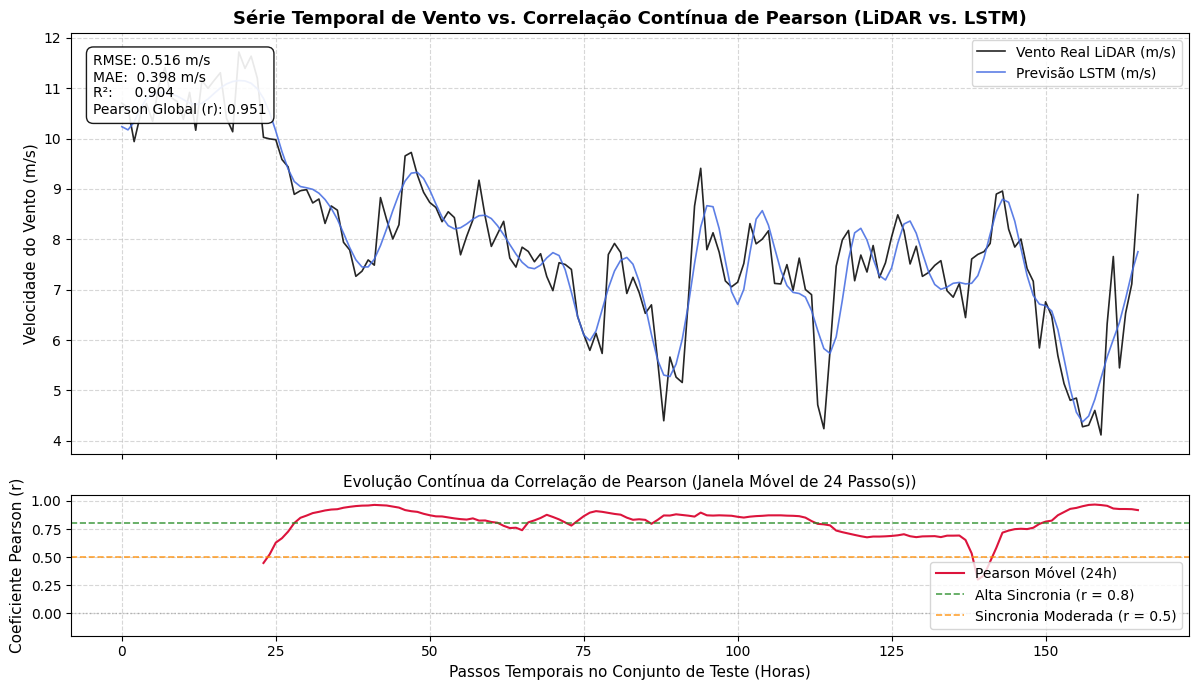

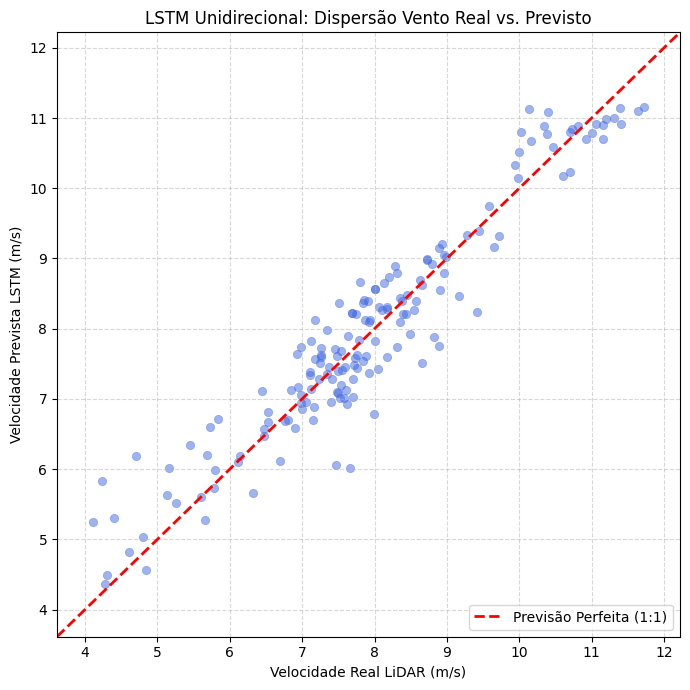

In [ ]:
# ==========================================
# 1. CARREGAMENTO E DIVISÃO TEMPORAL
# ==========================================
df = pd.read_parquet("data/approach_a.parquet")

features = ["ws100_lidar_clean"]
target = "ws100_lidar"

n = len(df)
train_df = df.iloc[: int(n * 0.7)]
val_df = df.iloc[int(n * 0.7) : int(n * 0.85)]
test_df = df.iloc[int(n * 0.85) :]

# ==========================================
# 2. NORMALIZAÇÃO SEPARADA (X e Y)
# ==========================================
scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_train_raw = scaler_x.fit_transform(train_df[features])
y_train_raw = scaler_y.fit_transform(train_df[[target]])

X_val_raw = scaler_x.transform(val_df[features])
y_val_raw = scaler_y.transform(val_df[[target]])

X_test_raw = scaler_x.transform(test_df[features])
y_test_raw = scaler_y.transform(test_df[[target]])

# ==========================================
# 3. JANELA DESLIZANTE (SLIDING WINDOW)
# ==========================================
def create_sequences(X_data, y_data, lookback=24):
  X_out, y_out = [], []
  for i in range(len(X_data) - lookback):
    X_out.append(X_data[i : i + lookback, :])
    y_out.append(y_data[i + lookback, 0])
  return np.array(X_out), np.array(y_out)

LOOKBACK = 24  # Usa as últimas 24h para prever a hora seguinte
X_train, y_train = create_sequences(X_train_raw, y_train_raw, LOOKBACK)
X_val, y_val = create_sequences(X_val_raw, y_val_raw, LOOKBACK)
X_test, y_test = create_sequences(X_test_raw, y_test_raw, LOOKBACK)

# ==========================================
# 4. MODELO LSTM UNIDIRECIONAL
# ==========================================
model = Sequential([
    LSTM(
        64, activation="tanh", input_shape=(X_train.shape[1], X_train.shape[2])
    ),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1),
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])

# Callbacks para otimização de treinamento
early_stop = EarlyStopping(
    monitor="val_loss", patience=7, restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=35,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)

# ==========================================
# 5. INFERÊNCIA E MÉTRICAS
# ==========================================
y_pred_scaled = model.predict(X_test)

y_real = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()

rmse = np.sqrt(mean_squared_error(y_real, y_pred))
mae = mean_absolute_error(y_real, y_pred)
r2 = r2_score(y_real, y_pred)
pearson_global = np.corrcoef(y_real, y_pred)[0, 1]

print(f"--- Métricas Globais do Conjunto de Teste ---")
print(
    f"RMSE: {rmse:.3f} m/s | MAE: {mae:.3f} m/s | R²: {r2:.3f} | Pearson (r):"
    f" {pearson_global:.3f}\n"
)

# ==========================================
# 6. CÁLCULO DA CORRELAÇÃO DE PEARSON MÓVEL (ROLLING)
# ==========================================
# Converte para Pandas Series para aplicar a janela deslizante de correlação
s_real = pd.Series(y_real)
s_pred = pd.Series(y_pred)

# Define a janela de correlação (ex.: 24 passos = 24 horas na Abordagem A)
WINDOW_CORR = 24
rolling_pearson = s_real.rolling(window=WINDOW_CORR).corr(s_pred)

# ==========================================
# 7. VISUALIZAÇÃO CONTÍNUA DUAL-PANEL (SÉRIE + CORRELAÇÃO MÓVEL)
# ==========================================
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(12, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)

# --- PAINEL SUPERIOR: Série Temporal Real vs. Previsto ---
ax1.plot(
    y_real,
    label="Vento Real LiDAR (m/s)",
    color="black",
    linewidth=1.2,
    alpha=0.85,
)
ax1.plot(
    y_pred,
    label="Previsão LSTM (m/s)",
    color="royalblue",
    linewidth=1.2,
    alpha=0.85,
)
ax1.set_title(
    "Série Temporal de Vento vs. Correlação Contínua de Pearson (LiDAR vs."
    " LSTM)",
    fontsize=13,
    fontweight="bold",
)
ax1.set_ylabel("Velocidade do Vento (m/s)", fontsize=11)
ax1.legend(loc="upper right", frameon=True, facecolor="white")
ax1.grid(True, linestyle="--", alpha=0.5)

# --- PAINEL INFERIOR: Correlação de Pearson Móvel ---
ax2.plot(
    rolling_pearson,
    color="crimson",
    linewidth=1.5,
    label=f"Pearson Móvel ({WINDOW_CORR}h)",
)
ax2.axhline(
    y=0.8,
    color="forestgreen",
    linestyle="--",
    linewidth=1.2,
    alpha=0.8,
    label="Alta Sincronia (r = 0.8)",
)
ax2.axhline(
    y=0.5,
    color="darkorange",
    linestyle="--",
    linewidth=1.2,
    alpha=0.8,
    label="Sincronia Moderada (r = 0.5)",
)
ax2.axhline(y=0.0, color="gray", linestyle=":", linewidth=1.0, alpha=0.5)

ax2.set_title(
    f"Evolução Contínua da Correlação de Pearson (Janela Móvel de"
    f" {WINDOW_CORR} Passo(s))",
    fontsize=11,
)
ax2.set_xlabel("Passos Temporais no Conjunto de Teste (Horas)", fontsize=11)
ax2.set_ylabel("Coeficiente Pearson (r)", fontsize=11)
ax2.set_ylim(-0.2, 1.05)
ax2.legend(loc="lower right", frameon=True, facecolor="white")
ax2.grid(True, linestyle="--", alpha=0.5)

# Adiciona caixa informativa de métricas no gráfico superior
metrics_text = (
    f"RMSE: {rmse:.3f} m/s\nMAE:  {mae:.3f} m/s\nR²:     {r2:.3f}\nPearson Global"
    f" (r): {pearson_global:.3f}"
)
ax1.text(
    0.02,
    0.95,
    metrics_text,
    transform=ax1.transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.9),
)

plt.tight_layout()
plt.show()

# ==========================================
# 8. GRÁFICO DE DISPERSÃO (1:1 SCATTER PLOT)
# ==========================================
plt.figure(figsize=(7, 7))
sns.scatterplot(
    x=y_real, y=y_pred, alpha=0.5, color="royalblue", edgecolor=None
)

min_val = min(y_real.min(), y_pred.min()) - 0.5
max_val = max(y_real.max(), y_pred.max()) + 0.5
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    lw=2,
    label="Previsão Perfeita (1:1)",
)

plt.title(
    "LSTM Unidirecional: Dispersão Vento Real vs. Previsto", fontsize=12
)
plt.xlabel("Velocidade Real LiDAR (m/s)", fontsize=10)
plt.ylabel("Velocidade Prevista LSTM (m/s)", fontsize=10)
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Formato de X_train (Amostras, Histórico, Atributos): (857, 24, 1)
Formato de y_train (Amostras, Horizonte Futuro): (857, 6)

Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.8713 - mae: 0.7196 - val_loss: 0.7570 - val_mae: 0.6664 - learning_rate: 0.0010
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.7248 - mae: 0.6609 - val_loss: 0.6911 - val_mae: 0.6323 - learning_rate: 0.0010
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.7036 - mae: 0.6504 - val_loss: 0.7139 - val_mae: 0.6620 - learning_rate: 0.0010
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.6858 - mae: 0.6410 - val_loss: 0.6575 - val_mae: 0.6093 - learning_rate: 0.0010
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.6623 - mae: 0.6295 - val_loss: 0.6591 - val_mae: 0.6164 - learning_rate: 0.0010
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.6578 - mae: 0.6245 - val_loss: 0.6594 - val_mae: 0.6258 - learning_rate: 0.0010
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.6373 - mae: 0.6151 - val_loss: 0.6347 - val_mae: 0.6025 - learning_rate: 0.0010
Epoch 8/50
27/27 ━━━━━━━

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step

   AVALIAÇÃO MULTI-STEP: ABORDAGEM A (HORIZONTE 1H A 6H)
Horizonte t+1h -> RMSE: 0.458 m/s | MAE: 0.353 m/s | R²: 0.925
Horizonte t+2h -> RMSE: 0.558 m/s | MAE: 0.432 m/s | R²: 0.887
Horizonte t+3h -> RMSE: 0.750 m/s | MAE: 0.594 m/s | R²: 0.794
Horizonte t+4h -> RMSE: 0.954 m/s | MAE: 0.776 m/s | R²: 0.666
Horizonte t+5h -> RMSE: 1.117 m/s | MAE: 0.899 m/s | R²: 0.535
Horizonte t+6h -> RMSE: 1.261 m/s | MAE: 0.994 m/s | R²: 0.398
--------------------------------------------------------
MÉTRICA GLOBAL (Média 6h) -> RMSE: 0.897 m/s | MAE: 0.675 m/s | R²: 0.704



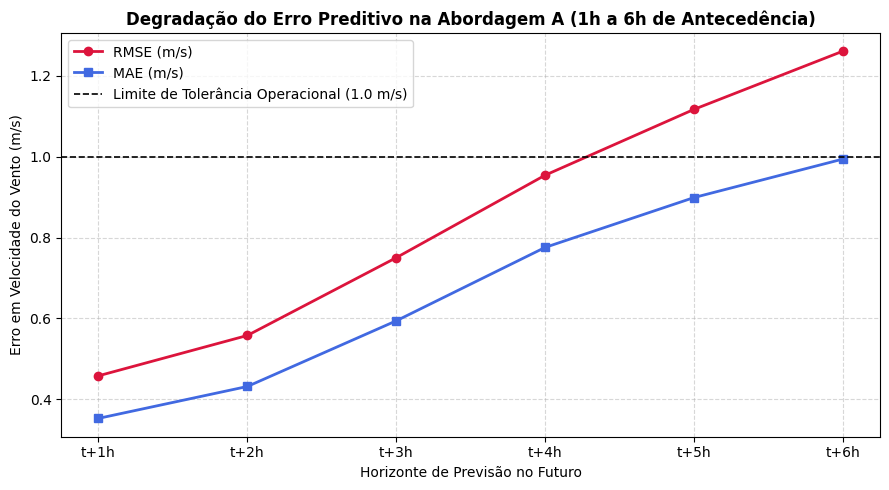

In [ ]:
# ==========================================
# 1. CARREGAMENTO E PREPARAÇÃO DOS DADOS (Abordagem A)
# ==========================================
df = pd.read_parquet("data/approach_a.parquet")

# Features de entrada (X): ERA5 e LiDAR filtrado por Wavelet
features = ["ws100_lidar_clean"]
# Alvo (Y): Verdade de campo do LiDAR
target = "ws100_lidar"

# ==========================================
# 2. DIVISÃO TEMPORAL CRONOLÓGICA (70% / 15% / 15%)
# ==========================================
n = len(df)
train_df = df.iloc[: int(n * 0.7)]
val_df = df.iloc[int(n * 0.7) : int(n * 0.85)]
test_df = df.iloc[int(n * 0.85) :]

# ==========================================
# 3. NORMALIZAÇÃO SEPARADA (X e Y)
# ==========================================
scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_train_raw = scaler_x.fit_transform(train_df[features])
y_train_raw = scaler_y.fit_transform(train_df[[target]])

X_val_raw = scaler_x.transform(val_df[features])
y_val_raw = scaler_y.transform(val_df[[target]])

X_test_raw = scaler_x.transform(test_df[features])
y_test_raw = scaler_y.transform(test_df[[target]])

# ==========================================
# 4. CRIAÇÃO DE SEQUÊNCIAS MULTI-STEP (24h -> 6h)
# ==========================================
def create_multistep_sequences(X_data, y_data, lookback=24, horizon=6):
  X_out, y_out = [], []
  # Garante que haja pontos suficientes para cobrir o lookback E o horizonte completo
  for i in range(len(X_data) - lookback - horizon + 1):
    X_out.append(X_data[i : i + lookback, :])
    # Extrai um vetor de 'horizon' (6) valores futuros para o alvo Y
    y_out.append(y_data[i + lookback : i + lookback + horizon, 0])
  return np.array(X_out), np.array(y_out)

LOOKBACK = 24  # 24 horas de histórico passado
HORIZON = 6  # 6 horas de previsão futura

X_train, y_train = create_multistep_sequences(
    X_train_raw, y_train_raw, LOOKBACK, HORIZON
)
X_val, y_val = create_multistep_sequences(
    X_val_raw, y_val_raw, LOOKBACK, HORIZON
)
X_test, y_test = create_multistep_sequences(
    X_test_raw, y_test_raw, LOOKBACK, HORIZON
)

print(
    f"Formato de X_train (Amostras, Histórico, Atributos): {X_train.shape}"
)  # Ex: (856, 24, 2)
print(f"Formato de y_train (Amostras, Horizonte Futuro): {y_train.shape}\n")  # Ex: (856, 6)

# ==========================================
# 5. MODELO LSTM MULTI-STEP (Dense de Saída = 6)
# ==========================================
model = Sequential([
    LSTM(
        64, activation="tanh", input_shape=(X_train.shape[1], X_train.shape[2])
    ),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(HORIZON),  # Saída com 6 neurônios (1 para cada hora futura)
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])

# Callbacks de controle
early_stop = EarlyStopping(
    monitor="val_loss", patience=7, restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)

# ==========================================
# 6. INFERÊNCIA E DESSESCALONAMENTO MATRICIAL
# ==========================================
y_pred_scaled = model.predict(X_test)  # Formato: (N_test, 6)

# Desescalonamento seguro de matrizes (N_test, 6) com scaler_y treinado em 1 coluna
y_real = scaler_y.inverse_transform(y_test.reshape(-1, 1)).reshape(-1, HORIZON)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(
    -1, HORIZON
)

# ==========================================
# 7. AVALIAÇÃO PASSO A PASSO (1H ATÉ 6H DE ANTECEDÊNCIA)
# ==========================================
print("\n========================================================")
print("   AVALIAÇÃO MULTI-STEP: ABORDAGEM A (HORIZONTE 1H A 6H)")
print("========================================================")

rmse_per_step = []
mae_per_step = []

for step in range(HORIZON):
  step_real = y_real[:, step]
  step_pred = y_pred[:, step]

  rmse_step = np.sqrt(mean_squared_error(step_real, step_pred))
  mae_step = mean_absolute_error(step_real, step_pred)
  r2_step = r2_score(step_real, step_pred)

  rmse_per_step.append(rmse_step)
  mae_per_step.append(mae_step)

  print(
      f"Horizonte t+{step+1}h -> RMSE: {rmse_step:.3f} m/s | MAE: {mae_step:.3f}"
      f" m/s | R²: {r2_step:.3f}"
  )

# Métricas Globais (Média de todo o horizonte)
rmse_global = np.sqrt(mean_squared_error(y_real, y_pred))
mae_global = mean_absolute_error(y_real, y_pred)
r2_global = r2_score(y_real.flatten(), y_pred.flatten())

print("--------------------------------------------------------")
print(
    f"MÉTRICA GLOBAL (Média 6h) -> RMSE: {rmse_global:.3f} m/s | MAE:"
    f" {mae_global:.3f} m/s | R²: {r2_global:.3f}"
)
print("========================================================\n")

# ==========================================
# 8. GRÁFICO DE DEGRADAÇÃO DO ERRO POR HORIZONTE
# ==========================================
plt.figure(figsize=(9, 5))
steps_labels = [f"t+{i+1}h" for i in range(HORIZON)]

plt.plot(
    steps_labels,
    rmse_per_step,
    marker="o",
    color="crimson",
    linewidth=2,
    label="RMSE (m/s)",
)
plt.plot(
    steps_labels,
    mae_per_step,
    marker="s",
    color="royalblue",
    linewidth=2,
    label="MAE (m/s)",
)

plt.axhline(
    y=1.0,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label="Limite de Tolerância Operacional (1.0 m/s)",
)

plt.title(
    "Degradação do Erro Preditivo na Abordagem A (1h a 6h de Antecedência)",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Horizonte de Previsão no Futuro", fontsize=10)
plt.ylabel("Erro em Velocidade do Vento (m/s)", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()